# A CNN to Predict Galaxy Photometric Redshifts
> Created: Aug. 2024 for the FSU Course: *Machine Learning in Physics* <br>
> Updated: Sun Sep 20 2025: Adapted for Introduction to ML course at AIMS South Africa<br>
> Harrison B. Prosper<br>


## Introduction

In this tutorial, we try to predict galaxy photometric redshifts given their  $64\times64$ pixel images in 5 color bands using a simple **convolutional neural network** (CNN) and a small subset of [GalaxyML](https://datalab.astro.ucla.edu/galaxiesml.html) data. 

## Running on Google Colab
If on Google Colab (https://colab.research.google.com), execute cell below.

In [1]:
try:
    import google.colab

    REPO = 'hbprosper/mlinphysics'
    
    url = f"https://raw.githubusercontent.com/{REPO}/refs/heads/main"
    !wget -q {url}/clone2colab.ipynb -O clone2colab.ipynb
    %run clone2colab.ipynb
    
    IN_COLAB = True
    
except ImportError:
    
    IN_COLAB = False

In [5]:
# standard system modules
import os, sys

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn
import torch.utils.data as dt

# module to access data in Hierarchical Data Format (HDF or H5 format)
import h5py

# module to plot pixelized images
import imageio.v3 as im

# module to reimport Python modules
import importlib

# module for saving/loading serialized Python objects
#import joblib

# module for shell utilities
import shutil

# ML in physics module
import mlinphysics.nn as mlp
import mlinphysics.utils.data as dat
import mlinphysics.utils.monitor as mon

plt.rcParams.update({
  "text.usetex": shutil.which('latex') is not None,
  "font.family": "sans-serif",
  "font.sans-serif": "Helvetica",
  "font.size": 10
})

## Set Computational Device

In [6]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n\tAvailable device: {str(DEVICE):4s}\n')


	Available device: cpu 



## Load Galaxy Images
Load galaxy images and normalize pixels by dividing each by 256.

In [8]:
base = '../data'
datafile = f'{base}/5x64x64GalaxyML.pt'

if dat.download(datafile):

    # Loading in memory-mapped mode keeps the data on disk and
    # loads only those data that are needed when they are 
    # needed.
    data      = torch.load(datafile, mmap=True)
    images    = data['image']
    redshifts = data['z']
    select    = redshifts <= 1
    
    images    = images[select]
    redshifts = redshifts[select]
    
    data_size = len(images)
    
    print(data_size)
    
else:
    raise RuntimeError(f'''
    Download of file {datafile} failed!
    ''')

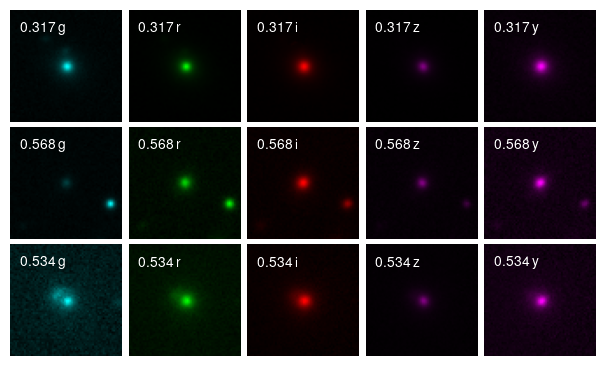

In [5]:
def plot_images(images, redshifts, n_rows=3):
    '''
Band Range (nm) Central(nm) Region
______________________________________________
g      ~400–550         477 blue-green
r      ~550–700         623 red
i      ~700–820         763 deep red / far red
z      ~820–920         913 near-IR
y     ~920–1100       ~1000 near-IR
    '''
    # ---- Make custom colormaps for each band ---- #
    cm_g = LinearSegmentedColormap.from_list("g_band", ["black", "cyan"])   #  477 nm
    cm_r = LinearSegmentedColormap.from_list("r_band", ["black", "lime"])   #  623 nm
    cm_i = LinearSegmentedColormap.from_list("i_band", ["black", "red"])    #  763 nm
    cm_z = LinearSegmentedColormap.from_list("z_band", ["black", "purple"]) #  913 nm
    cm_y = LinearSegmentedColormap.from_list("y_band", ["black", "magenta"])# 1000 nm

    cmaps= [cm_g, cm_r, cm_i, cm_z, cm_y]
    band = ["g", "r", "i", "z", "y"]

    n_cols = 5
    n = n_cols * n_rows
    f_size = (n_cols * 1.2, n_rows * 1.2)

    fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=f_size)

    # note use of flatten() to convert the matrix
    # of shape (nrows, ncols) to a 1-d array.
    axs = axs.flatten()

    j = -1
    for image, z in zip(images[:n_rows], redshifts[:n_rows]):
        for i in range(n_cols):
            j += 1
            ax = axs[j]
            ax.axis('off')
            ax.imshow(image[i], cmap=cmaps[i])#, origin="lower")

            # Note: (x, y) coordinates are in pixels,
            # where (0, 0) is the upper left corner
            ax.text(5, 12, f'{z:6.3f}\t{band[i]:s}', color='white')

    fig.tight_layout(pad=0.5)
    plt.savefig('galaxy_images.png')
    
plot_images(images, redshifts)

## Configuration

In [16]:
# name of model
# -----------------------------------------
name = 'z'

# choose whether to create or load a configuration file
load_existing_config = False

if load_existing_config:
    config = mlp.Config(f'{name}.yaml')
else:
    # create new configuration
    config = mlp.Config(name, dirname='z2')

    # training configuration
    # -----------------------------------------
    train_size = 20_000
    test_size  =  2_000
    val_size   = data_size - train_size - test_size
    batch_size =  5
    
    config('train_size', train_size)           # set training sample size
    config('test_size',  test_size)            # set test sample size
    config('val_size',   val_size)             # set validation sample size
    config('batch_size', batch_size)
    
    config('monitor_step',  100)  # set monitor training every n (=10) iterations
    config('delete', True)        # delete losses file before training, if True
    config('frac', 0.015)         # save model if average loss decreases by more
                                  # than frac percent

    # optimizer / scheduler configuration
    # -----------------------------------------
    # a step comprises a given number of iterations
    config('n_steps', 2)          # number of training steps
    config('n_iters_per_step', 10_000)
    config('n_iterations', config('n_iters_per_step')*config('n_steps'))

    config('base_lr', 1.e-4)      # initial learning rate
    config('gamma', 0.5)          # learning rate scale factor

    print(f'\nSave configuration to file {config.cfg_filename}\n')
    config.save()

print(config)


Save configuration to file runs/z2/z_config.yaml

name: z
file:
  losses: runs/z2/z_losses.csv
  params: runs/z2/z_params.pth
  init_params: runs/z2/z_init_params.pth
  plots: runs/z2/z_plots.png
train_size: 20000
test_size: 2000
val_size: 871
batch_size: 5
monitor_step: 100
delete: true
frac: 0.015
n_steps: 2
n_iters_per_step: 10000
n_iterations: 20000
base_lr: 0.0001
gamma: 0.5



## Prepare Datasets and DataLoaders

### Datasets

In [17]:
importlib.reload(dat)

train_size = config('train_size')
val_size   = config('val_size')
test_size  = config('test_size')

# change shape of target to (N, 1)
redshifts = redshifts.view(-1, 1)

# training dataset (this defines the empirical risk to be minimized)
print('training data')
train_data = dat.Dataset(
    images,
    start=0,
    end=train_size, 
    targets=redshifts)

# a random subset of the training data to check for overtraining
# by comparing with the empirical risk from the validation set
print('training data for validation')
train_data_val = dat.Dataset(
    images,
    start=0,
    end=train_size,
    targets=redshifts,
    random_sample_size=val_size)

# validation dataset (for monitoring training)
print('validation data')
val_data = dat.Dataset(
    images,
    start=train_size,
    end=train_size + val_size,
    targets=redshifts)

# test dataset
print('test data')
test_data= dat.Dataset(
    images,
    start=train_size + val_size,
    end=train_size + val_size + test_size,
    targets=redshifts)

training data
Dataset
  shape of x: torch.Size([20000, 5, 64, 64])
  shape of y: torch.Size([20000, 1])

training data for validation
Dataset
  shape of x: torch.Size([871, 5, 64, 64])
  shape of y: torch.Size([871, 1])

validation data
Dataset
  shape of x: torch.Size([871, 5, 64, 64])
  shape of y: torch.Size([871, 1])

test data
Dataset
  shape of x: torch.Size([2000, 5, 64, 64])
  shape of y: torch.Size([2000, 1])



### DataLoaders

In [18]:
print('train data loader')
train_loader = dat.DataLoader(train_data,
                              batch_size=config('batch_size'),
                              num_iterations=config('n_iterations'),
                              shuffle=True)

print('train data loader for validation')
train_loader_val = dat.DataLoader(train_data_val,
                                  batch_size=len(train_data_val))

print('validation data loader')
val_loader  = dat.DataLoader(val_data,
                             batch_size=len(val_data))

print('test data loader')
test_loader = dat.DataLoader(test_data,
                             batch_size=len(test_data))

train data loader
DataLoader
  Number of iterations has been specified
  maxiter:           20000
  batch_size:            5
  shuffle_step:       4000

train data loader for validation
DataLoader
  maxiter:               1
  batch_size:          871
  shuffle_step:          1

validation data loader
DataLoader
  maxiter:               1
  batch_size:          871
  shuffle_step:          1

test data loader
DataLoader
  maxiter:               1
  batch_size:         2000
  shuffle_step:          1



## Build model

In [19]:
class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels, padding=1, dropout=0.3):

        super().__init__()

        kernel_size = 2*padding + 1

        self.conv = nn.Conv2d(in_channels=in_channels,
                               out_channels=out_channels,
                               kernel_size=kernel_size,
                               stride=1,
                               padding=padding)
        self.nonlinearity = mlp.Sin()
        self.maxpool = nn.MaxPool2d(kernel_size=(2, 2), stride=2)
        self.batchnorm = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.conv(x)
        x = self.nonlinearity(x)
        x = self.batchnorm(x)
        x = self.dropout(x)
        x = self.maxpool(x)
        return x

class GalaxyRedshiftRegressor(mlp.Model):
    def __init__(self, image_size=64, 
                 channels=[5, 8, 10, 12, 14, 16], 
                 padding=1, 
                 dropout=0.4):
        super().__init__()

        # number of convolutional layers
        nlayers = len(channels)-1

        # number of inputs into regression layer
        final_image_size = int(image_size /  2**nlayers)
        ninputs = channels[-1] * final_image_size**2

        self.net = nn.Sequential()
        for i in range(nlayers):
            self.net.append(ConvBlock(channels[i], 
                                      channels[i+1], 
                                      padding, 
                                      dropout=dropout)) 
        self.net.append(nn.Flatten())
        self.net.append(nn.Linear(ninputs, 1))

    def forward(self, x):
        return self.net(x)

## Instantiate model

In [20]:
importlib.reload(mlp)
config('channels', [5, 8, 10, 12, 14, 16])
config('dropout', 0.1)
config.save()

model = GalaxyRedshiftRegressor(
    channels=config('channels'),
    dropout=config('dropout')).to(DEVICE)
print(model)
print()

print('number of parameters:', mlp.number_of_parameters(model))
print()

GalaxyRedshiftRegressor(
  (net): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(5, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlinearity): Sin()
      (maxpool): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
      (batchnorm): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): ConvBlock(
      (conv): Conv2d(8, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlinearity): Sin()
      (maxpool): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
      (batchnorm): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (2): ConvBlock(
      (conv): Conv2d(10, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlinearity): Sin()
      (maxpool): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation

## Instantiate Training Objects
  1. `optimizer`
  1. `objective`
  1. `scheduler`
  2. `losswriter`

In [21]:
optimizer = torch.optim.Adam(model.parameters(), lr=config('base_lr'))

objective = mlp.Objective(model, nn.MSELoss()).to(DEVICE)

# Instantiate learning rate step scheduler
scheduler = mlp.LRStepScheduler(
    optimizer,  
    n_steps=config('n_steps'), 
    n_iters_per_step=config('n_iters_per_step'), 
    base_lr=config('base_lr'), 
    gamma=config('gamma')
)

# Instantiate object that saves average losses to
# a csv file for realtime monitoring, as well as
# the model with the lowest average loss
monitor = mon.Monitor(
    config('n_iterations'),
    config('file/losses'),
    monitorstep=config('monitor_step'),
    newlossfile=True,
    frac=config('frac'),
    model=model,
    paramsfile=config('file/params')
)

number of milestones:          1

Step | Milestone | LR
-----------------------------
   0 |         0 | 1.0e-04   
-----------------------------
   1 |     10000 | 5.0e-05   



## Define Trainer

In [22]:
def train(objective, optimizer, scheduler, monitor,
          train_loader, train_small_loader, val_loader):
    
    for x, y in train_loader:

        # set mode to training so that training-specific
        # operations such as dropout, etc., are enabled.
        objective.train()

        # clear all gradients
        optimizer.zero_grad()

        # compute empirical risk
        R = objective(x, y)

        # compute gradients
        R.backward()

        # take one step downhill in the empirical risk landscape
        optimizer.step()

        # check whether to update learning rate
        scheduler.step()

        if monitor.step():

            # compute average losses on training and validation data
            t_loss = mlp.compute_avg_loss(objective, train_small_loader)
            v_loss = mlp.compute_avg_loss(objective, val_loader)

            # return current learning rate
            lr = scheduler.lr()

            # update loss file
            monitor(t_loss, v_loss, lr)

In [7]:
TRAIN = True

if TRAIN:

    monitor.start()
    
    train(objective, optimizer, scheduler, monitor,
          train_loader, train_loader_val, val_loader)
    
    monitor.end()

## Test Model

In [29]:
def plot_reconstruction(z, zpred, 
                xmin=0.0, xmax=1.0, 
                filename='redshift.png'):

    z, zpred = z.flatten(), zpred.flatten()
    
    # create an empty figure
    fig = plt.figure(figsize=(8, 4))
    
    # add a subplot to it
    nrows, ncols = 1, 2
    ax1  = fig.add_subplot(nrows,ncols, 1)
    ax2  = fig.add_subplot(nrows,ncols, 2)

    ax = ax1

    nx = 5
    xmarks = np.linspace(xmin, xmax, nx)
    
    # axis limits
    ax.set_xlim((xmin, xmax))
    ax.set_xlabel('$z$', fontsize=16)
    ax.set_xticks(xmarks)
    
    ax.set_ylim((xmin, xmax))
    ax.set_ylabel('$z_{pred}$', fontsize=16)
    ax.set_yticks(xmarks)

    # plot data in latent space
    ax.scatter(z, zpred, color='blue', s=0.2)
    ax.plot([xmin, xmax], [xmin, xmax], 
            color='red', linewidth=2, linestyle='dashed')
    
    ax.grid()

    ax = ax2
    
    # axis limits
    dz = zpred - z
    zmean = dz.mean()
    zstd  = dz.std()
    
    xmin, xmax = -1.0, 1.0
    nx = 5
    xmarks = np.linspace(xmin, xmax, nx)
    ax.set_xlim((xmin, xmax))
    ax.set_xlabel(r'$z_{pred} - z$', fontsize=16)
    ax.set_xticks(xmarks)
    
    #ax.set_ylim((ymin, ymax))

    res = ax.hist(dz, bins=100, 
            range=(xmin, xmax), 
            color='blue',
            density=True,
            alpha=0.4)
    ax.text(0.25, 7.00, f'mean: {zmean:8.3f}', fontsize=12)
    ax.text(0.25, 6.20, f' std: {zstd:8.3f}',  fontsize=12)
    
    fig.tight_layout()
    
    plt.savefig(filename)
    
    #plt.show()

In [32]:
model.load('runs/z/redshift_params.pth')
print(model)

GalaxyRedshiftRegressor(
  (net): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(5, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlinearity): Sin()
      (maxpool): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
      (batchnorm): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): ConvBlock(
      (conv): Conv2d(8, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlinearity): Sin()
      (maxpool): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
      (batchnorm): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (2): ConvBlock(
      (conv): Conv2d(10, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlinearity): Sin()
      (maxpool): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation

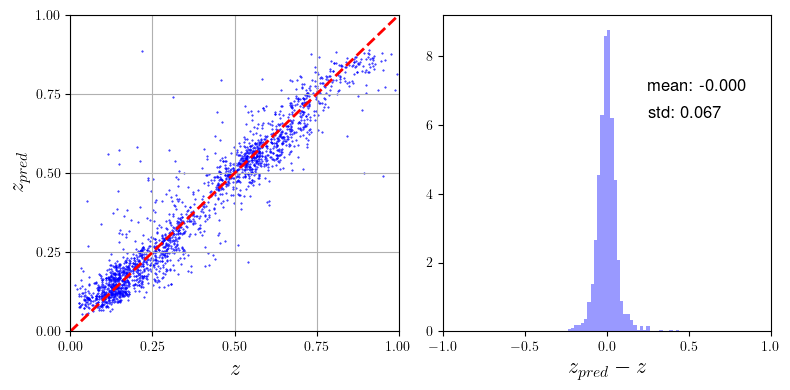

In [33]:
%matplotlib inline

#model.load(config('file/params'))
x, z  = next(iter(test_loader))
z_hat = model(x)

z     = z.detach().cpu().numpy().flatten()
z_hat = z_hat.detach().cpu().numpy().flatten()

plot_reconstruction(z, z_hat)